# Confidence Score Threshold Analysis

**Goal:** Find the threshold on UniTable's structure decoder mean log probability that achieves **100% precision** — no bad tables (label=0) pass through to UniTable — while maximising the number of good tables (label=1) captured.

A table is labelled:
- **1 (positive):** TEDS ≥ 0.90 — UniTable handles it well, attempt automatically
- **0 (negative):** TEDS ≤ 0.85 — UniTable struggles, send to human review

**Confidence score:** mean log probability of each structure token chosen by the decoder. Closer to 0 → more confident.

In [ ]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
)

# ── Labeling thresholds ───────────────────────────────────────────────────────
TEDS_HIGH = 0.90   # TEDS >= this → label 1 (good)
TEDS_LOW  = 0.85   # TEDS <= this → label 0 (bad)

# Load the most recent structure-only confidence scores CSV
csvs = sorted(glob.glob("../data/confidence_scores_[0-9]*.csv"))
assert csvs, "No confidence_scores CSV found — run scripts/confidence_score_modal.py::main first"
CSV = csvs[-1]
print(f"Using: {CSV}")

df_raw = pd.read_csv(CSV)

# Support both old column name (mean_log_prob) and new (conf_structure)
if "conf_structure" in df_raw.columns:
    df_raw = df_raw.rename(columns={"conf_structure": "mean_log_prob"})

# Re-label using chosen TEDS thresholds
df_raw["label_new"] = df_raw["teds_score"].apply(
    lambda s: 1 if s >= TEDS_HIGH else (0 if s <= TEDS_LOW else -1)
)
df = df_raw[df_raw["label_new"] != -1].copy()
df["label"] = df["label_new"]

print(f"\nTEDS thresholds: positive ≥ {TEDS_HIGH}  |  negative ≤ {TEDS_LOW}")
print(f"Tables: {len(df)}  |  Label 1: {(df['label']==1).sum()}  |  Label 0: {(df['label']==0).sum()}")
print(f"mean_log_prob range: [{df['mean_log_prob'].min():.6f}, {df['mean_log_prob'].max():.6f}]")

Using: ../confidence_scores_20260412_014530.csv

TEDS thresholds: positive ≥ 0.97  |  negative ≤ 0.85
Tables: 9026  |  Label 1: 1321  |  Label 0: 7705
mean_log_prob range: [-0.174757, -0.000002]


## 1. ROC-AUC

In [44]:
auc = roc_auc_score(df["label"], df["mean_log_prob"])
print(f"ROC-AUC: {auc:.4f}")
print(f"(Trained classifier baseline: 0.58–0.66)")

ROC-AUC: 0.8420
(Trained classifier baseline: 0.58–0.66)


## 2. Threshold sweep — wide view

Sweeping from very permissive to very strict to understand the full precision/recall landscape.

In [45]:
def sweep(thresholds):
    rows = []
    for t in thresholds:
        pred = (df["mean_log_prob"] >= t).astype(int)
        if pred.sum() == 0:
            continue
        tp = int(((pred == 1) & (df["label"] == 1)).sum())
        fp = int(((pred == 1) & (df["label"] == 0)).sum())
        fn = int(((pred == 0) & (df["label"] == 1)).sum())
        prec = tp / (tp + fp)
        rec  = tp / (tp + fn)
        rows.append({
            "threshold": t,
            "passed":    tp + fp,
            "TP": tp, "FP": fp,
            "precision": round(prec, 4),
            "recall":    round(rec, 4),
        })
    return pd.DataFrame(rows)

wide_thresholds = np.concatenate([
    np.arange(-0.10,    -0.01,    0.01),
    np.arange(-0.010,   -0.001,   0.001),
    np.arange(-0.0010,  -0.0001,  0.0001),
    np.arange(-0.00010,  0.00001, 0.00001),
])

df_sweep = sweep(wide_thresholds)
print(df_sweep.to_string(index=False))

 threshold  passed   TP   FP  precision  recall
  -0.10000    9005 1320 7685     0.1466  0.9992
  -0.09000    8997 1320 7677     0.1467  0.9992
  -0.08000    8973 1320 7653     0.1471  0.9992
  -0.07000    8924 1320 7604     0.1479  0.9992
  -0.06000    8830 1320 7510     0.1495  0.9992
  -0.05000    8652 1319 7333     0.1525  0.9985
  -0.04000    8304 1314 6990     0.1582  0.9947
  -0.03000    7704 1304 6400     0.1693  0.9871
  -0.02000    6495 1268 5227     0.1952  0.9599
  -0.01000    4279 1154 3125     0.2697  0.8736
  -0.00900    3990 1130 2860     0.2832  0.8554
  -0.00800    3675 1107 2568     0.3012  0.8380
  -0.00700    3301 1077 2224     0.3263  0.8153
  -0.00600    2953 1036 1917     0.3508  0.7843
  -0.00500    2565  973 1592     0.3793  0.7366
  -0.00400    2124  880 1244     0.4143  0.6662
  -0.00300    1751  798  953     0.4557  0.6041
  -0.00200    1294  664  630     0.5131  0.5026
  -0.00100     795  517  278     0.6503  0.3914
  -0.00090     742  495  247     0.6671 

## 3. Precision–Recall curve

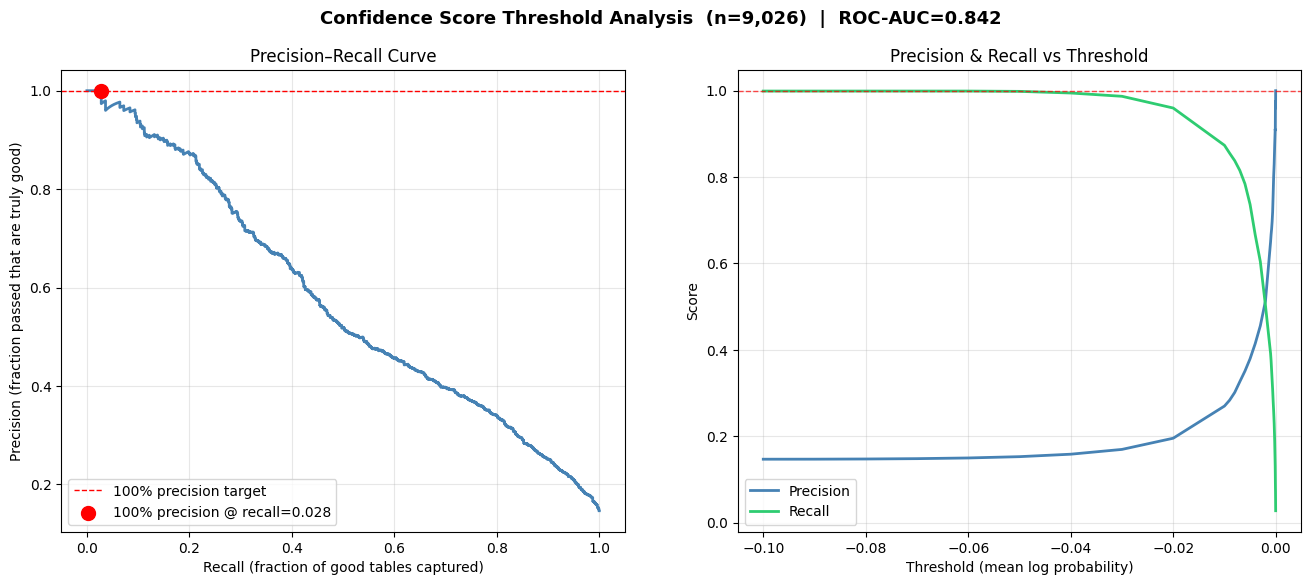

In [46]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    df["label"], df["mean_log_prob"]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Precision–Recall curve ──────────────────────────────────────────────
ax = axes[0]
ax.plot(recall_curve, precision_curve, color="steelblue", linewidth=2)
ax.axhline(y=1.0, color="red", linestyle="--", linewidth=1, label="100% precision target")

perfect_mask = precision_curve == 1.0
if perfect_mask.any():
    best_recall_at_perfect = recall_curve[perfect_mask].max()
    ax.scatter([best_recall_at_perfect], [1.0], color="red", zorder=5, s=100,
               label=f"100% precision @ recall={best_recall_at_perfect:.3f}")

ax.set_xlabel("Recall (fraction of good tables captured)")
ax.set_ylabel("Precision (fraction passed that are truly good)")
ax.set_title("Precision–Recall Curve")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Right: Precision & Recall vs threshold ────────────────────────────────────
ax2 = axes[1]
ax2.plot(df_sweep["threshold"], df_sweep["precision"], label="Precision", color="steelblue", linewidth=2)
ax2.plot(df_sweep["threshold"], df_sweep["recall"],    label="Recall",    color="#2ecc71",  linewidth=2)
ax2.axhline(y=1.0, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax2.set_xlabel("Threshold (mean log probability)")
ax2.set_ylabel("Score")
ax2.set_title("Precision & Recall vs Threshold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f"Confidence Score Threshold Analysis  (n={len(df):,})  |  ROC-AUC={auc:.3f}",
             fontsize=13, fontweight="bold")
import os; os.makedirs("results", exist_ok=True)
plt.savefig("results/confidence_threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Fine-grained sweep in the high-precision zone

Zoom into the region where precision ≥ 0.90 to find the best operating point.

In [ ]:
# Identify the coarse threshold where precision first exceeds 0.90
high_prec = df_sweep[df_sweep["precision"] >= 0.90]
if not high_prec.empty:
    coarse_start = high_prec["threshold"].min()
else:
    coarse_start = -0.0002

fine_thresholds = np.arange(coarse_start, 0.0, abs(coarse_start) / 50)
df_fine = sweep(fine_thresholds)

print("High-precision zone (precision ≥ 0.90):")
print(df_fine[df_fine["precision"] >= 0.90].to_string(index=False))

High-precision zone (precision ≥ 0.90):
 threshold  passed  TP  FP  precision  recall
 -0.000030      80  78   2     0.9750  0.0590
 -0.000029      79  77   2     0.9747  0.0583
 -0.000029      78  76   2     0.9744  0.0575
 -0.000028      78  76   2     0.9744  0.0575
 -0.000028      74  72   2     0.9730  0.0545
 -0.000027      73  71   2     0.9726  0.0537
 -0.000026      72  70   2     0.9722  0.0530
 -0.000026      69  67   2     0.9710  0.0507
 -0.000025      69  67   2     0.9710  0.0507
 -0.000025      69  67   2     0.9710  0.0507
 -0.000024      69  67   2     0.9710  0.0507
 -0.000023      69  67   2     0.9710  0.0507
 -0.000023      67  65   2     0.9701  0.0492
 -0.000022      65  63   2     0.9692  0.0477
 -0.000022      65  63   2     0.9692  0.0477
 -0.000021      64  62   2     0.9688  0.0469
 -0.000020      62  60   2     0.9677  0.0454
 -0.000020      61  59   2     0.9672  0.0447
 -0.000019      60  58   2     0.9667  0.0439
 -0.000019      59  57   2     0.9661  0

## 5. 100% Precision threshold

The exact threshold where no bad table passes through.

In [48]:
perfect = df_fine[df_fine["precision"] == 1.0]
if perfect.empty:
    # Fall back to full sweep
    perfect = df_sweep[df_sweep["precision"] == 1.0]

if perfect.empty:
    print("100% precision not reached within the swept range.")
    print("Highest precision achieved:")
    print(df_fine.loc[df_fine["precision"].idxmax()])
else:
    # Best = lowest threshold that still gives 100% precision (most recall)
    best = perfect.loc[perfect["recall"].idxmax()]
    total_pos = (df["label"] == 1).sum()

    print("=" * 55)
    print(f"100% Precision threshold: {best['threshold']:.6f}")
    print("=" * 55)
    print(f"  Good tables captured (TP):   {best['TP']} / {total_pos}  ({100*best['recall']:.1f}% recall)")
    print(f"  Bad tables that slip through: {best['FP']}")
    print(f"  Total tables passed to UniTable: {int(best['passed'])}")
    print(f"  Tables sent to human review: {len(df) - int(best['passed'])}  ({100*(len(df)-int(best['passed']))/len(df):.1f}%)")
    print()
    print("All 100%-precision operating points (lowest threshold = best recall):")
    print(perfect.to_string(index=False))

100% Precision threshold: -0.000010
  Good tables captured (TP):   36.0 / 1321  (2.7% recall)
  Bad tables that slip through: 0.0
  Total tables passed to UniTable: 36
  Tables sent to human review: 8990  (99.6%)

All 100%-precision operating points (lowest threshold = best recall):
 threshold  passed  TP  FP  precision  recall
 -0.000010      36  36   0        1.0  0.0273
 -0.000008      28  28   0        1.0  0.0212
 -0.000006      20  20   0        1.0  0.0151
 -0.000004      12  12   0        1.0  0.0091
 -0.000002       2   2   0        1.0  0.0015
